In [40]:
import sys
!{sys.executable} -m pip install torch

import random
import torch
import timeit
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# -------------------------------------------------------
# (1) Generate data as Python matrices (list of lists)
# -------------------------------------------------------
m_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def generate_matrices(m):
    W = [[random.random() for _ in range(m)] for _ in range(90)]
    X = [[random.random() for _ in range(110)] for _ in range(m)]
    return W, X


In [42]:
# -------------------------------------------------------
# (2) Plain Python matrix multiplication (nested loops)
# -------------------------------------------------------
def plain_matmul(W, X, m):
    rows_W = len(W)      # 90
    cols_X = len(X[0])   # 110
    result = [[0.0] * cols_X for _ in range(rows_W)]
    for i in range(rows_W):
        for j in range(cols_X):
            for k in range(m):
                result[i][j] += W[i][k] * X[k][j]
    return result


In [43]:
# -------------------------------------------------------
# (3) Convert to torch.tensor
# -------------------------------------------------------
def to_tensors(W, X):
    W_t = torch.tensor(W)
    X_t = torch.tensor(X)
    return W_t, X_t


In [44]:
# -------------------------------------------------------
# (4) Vectorized multiplication using torch.mm
# -------------------------------------------------------
def vectorized_matmul(W_t, X_t):
    return torch.mm(W_t, X_t)


In [ ]:
# -------------------------------------------------------
# (5) Timing experiments for each m value
# -------------------------------------------------------
plain_times = []
vec_times = []

for m in m_values:
    W, X = generate_matrices(m)
    W_t, X_t = to_tensors(W, X)

    t_plain = timeit.timeit(lambda: plain_matmul(W, X, m), number=10)
    t_vec   = timeit.timeit(lambda: vectorized_matmul(W_t, X_t), number=100)

    plain_times.append(t_plain / 10)
    vec_times.append(t_vec / 100)

print(f"m={m:3d} | plain: {t_plain/10:.4f}s | vec: {t_vec/100:.6f}s | speedup: {(t_plain/10)/(t_vec/100):.1f}x")

m= 10 | plain: 0.0218s | vec: 0.000006s | speedup: 3448.0x
m= 20 | plain: 0.0354s | vec: 0.000036s | speedup: 992.5x
m= 30 | plain: 0.0767s | vec: 0.000017s | speedup: 4591.5x
m= 40 | plain: 0.0939s | vec: 0.000015s | speedup: 6338.4x
m= 50 | plain: 0.1107s | vec: 0.000027s | speedup: 4030.1x
m= 60 | plain: 0.1459s | vec: 0.000022s | speedup: 6655.8x
m= 70 | plain: 0.1573s | vec: 0.000025s | speedup: 6225.4x
m= 80 | plain: 0.1585s | vec: 0.000024s | speedup: 6723.5x
m= 90 | plain: 0.1685s | vec: 0.000018s | speedup: 9473.3x
m=100 | plain: 0.1868s | vec: 0.000030s | speedup: 6182.0x


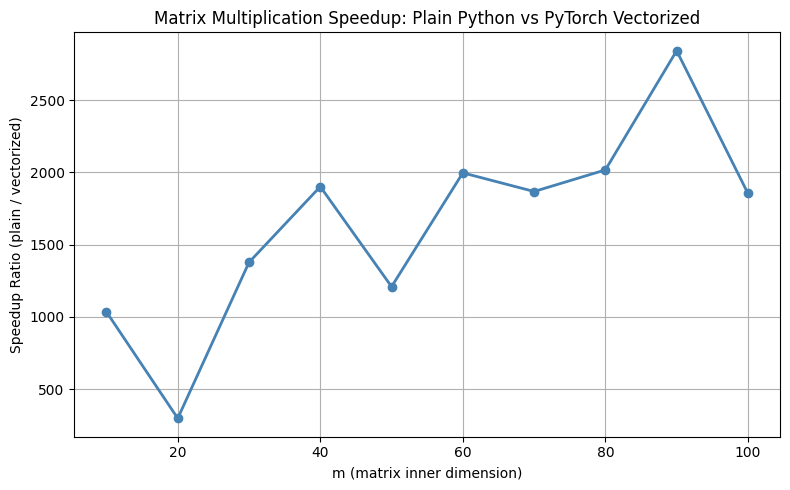

In [46]:
# -------------------------------------------------------
# (6) Plot speedup ratio with matplotlib
# -------------------------------------------------------
speedups = [p / v for p, v in zip(plain_times, vec_times)]

plt.figure(figsize=(8, 5))
plt.plot(m_values, speedups, marker='o', linewidth=2, color='steelblue')
plt.xlabel('m (matrix inner dimension)')
plt.ylabel('Speedup Ratio (plain / vectorized)')
plt.title('Matrix Multiplication Speedup: Plain Python vs PyTorch Vectorized')
plt.grid(True)
plt.tight_layout()
plt.savefig('speedup_plot.png', dpi=150)
plt.show()